# Problem 2 — RNN/LSTM: Jena Climate Temperature Forecasting

**Task:** Predict the temperature 24 hours ahead from a sliding window of historical observations.
**Target:** RMSLE < 1.

**Notebook outline:**
1. Environment setup & seeds
2. Data download & exploration
3. Preprocessing: resample, normalise, justify every step
4. Sliding-window dataset generator (3 window sizes)
5. Modelling: SimpleRNN → LSTM → Stacked LSTM → Bidirectional LSTM
6. Results table
7. Evaluation: predicted vs actual, best/worst windows

## 1. Environment Setup

Fix all random seeds so results are reproducible. We also pin TensorFlow's global seed to cover GPU ops.

In [1]:
import os, random, time
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pathlib import Path


class EpochProgress(keras.callbacks.Callback):
    """Per-epoch timer + within-epoch tqdm progress bar."""
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
        total  = self.params.get('epochs', '?')
        steps  = self.params.get('steps', None)
        self._pbar = tqdm(
            total=steps, desc=f'Epoch {epoch+1}/{total}',
            unit='batch', leave=False, ncols=90)

    def on_train_batch_end(self, batch, logs=None):
        self._pbar.update(1)
        if logs:
            self._pbar.set_postfix(loss=f"{logs.get('loss', 0):.4f}")

    def on_epoch_end(self, epoch, logs=None):
        self._pbar.close()
        logs    = logs or {}
        elapsed = time.time() - self._t0
        total   = self.params.get('epochs', '?')
        metrics = ' | '.join(
            f'{k}={v:.4f}'
            for k, v in logs.items()
            if not k.startswith('learning_rate')
        )
        print(f'Epoch {epoch+1}/{total} — {elapsed:.1f}s  {metrics}', flush=True)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FIGURES_DIR = Path('../figures')
MODELS_DIR  = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

2026-06-13 11:06:25.714656: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-13 11:06:26.756114: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-13 11:06:26.756175: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-06-13 11:06:26.881531: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-13 11:06:29.480999: W tensorflow/stream_executor/platform/de

TensorFlow: 2.10.0
GPU available: []


2026-06-13 11:06:32.691213: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-06-13 11:06:32.691978: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-06-13 11:06:32.692115: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (e298bf024cde): /proc/driver/nvidia/version does not exist


## 2. Data Download

The Jena Climate dataset contains ~420,000 rows of weather measurements recorded every 10 minutes at the Max Planck Institute for Biogeochemistry in Jena, Germany (2009–2016).

`kagglehub` handles authentication and caching; the returned path is used directly so the notebook is portable.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mnassrib/jena-climate")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1


In [3]:
# Locate the CSV inside the downloaded directory
def find_csv(base):
    for p in Path(base).rglob('*.csv'):
        return p
    raise FileNotFoundError(f'No CSV found under {base}')

csv_path = find_csv(path)
print('CSV file:', csv_path)

df_raw = pd.read_csv(csv_path)
print('Shape:', df_raw.shape)
df_raw.head()

CSV file: /root/.cache/kagglehub/datasets/mnassrib/jena-climate/versions/1/jena_climate_2009_2016.csv
Shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Data Exploration

Before preprocessing we examine:
- The date range and frequency of measurements.
- The temperature series over the full range (seasonality, trends).
- Missing values and outliers.

In [4]:
# Identify and parse the datetime column
date_col = df_raw.columns[0]
print('Columns:', df_raw.columns.tolist())
print('Date column:', date_col)

df_raw[date_col] = pd.to_datetime(df_raw[date_col], format='%d.%m.%Y %H:%M:%S')
df_raw = df_raw.set_index(date_col).sort_index()

# Identify temperature column
temp_col = [c for c in df_raw.columns if 'T (' in c or 'temp' in c.lower() or 'T (degC)' in c]
if not temp_col:
    temp_col = [df_raw.columns[0]]  # fallback
TEMP_COL = temp_col[0]
print(f'Temperature column: "{TEMP_COL}"')

print('\nDate range:', df_raw.index[0], '→', df_raw.index[-1])
print('Total rows:', len(df_raw))
print('Approx. frequency:', pd.infer_freq(df_raw.index[:100]))

Columns: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Date column: Date Time
Temperature column: "T (degC)"

Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Total rows: 420551
Approx. frequency: 10T


In [5]:
# Check for missing values
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None — dataset is complete.')

Missing values per column:
None — dataset is complete.


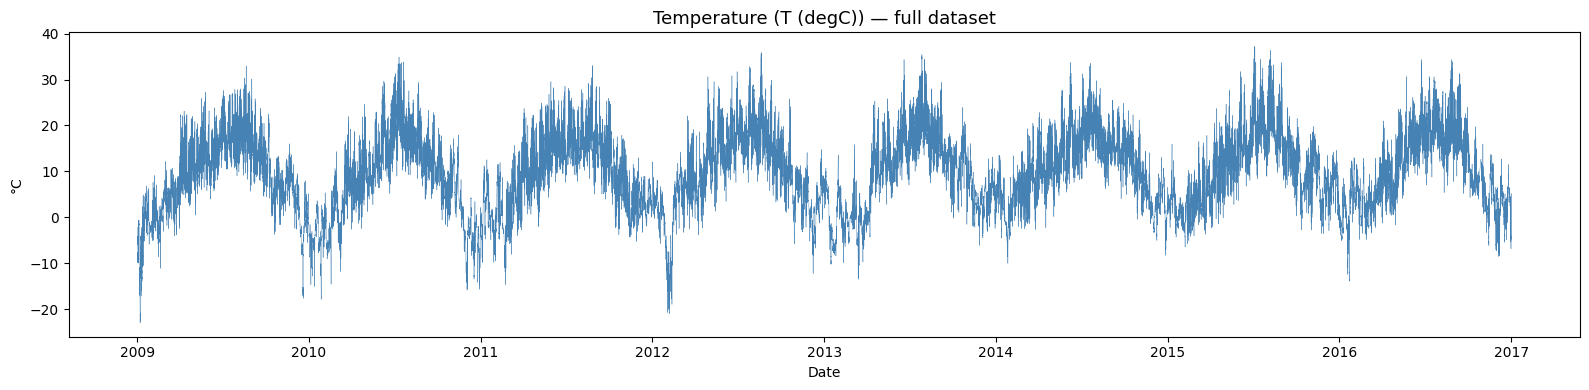

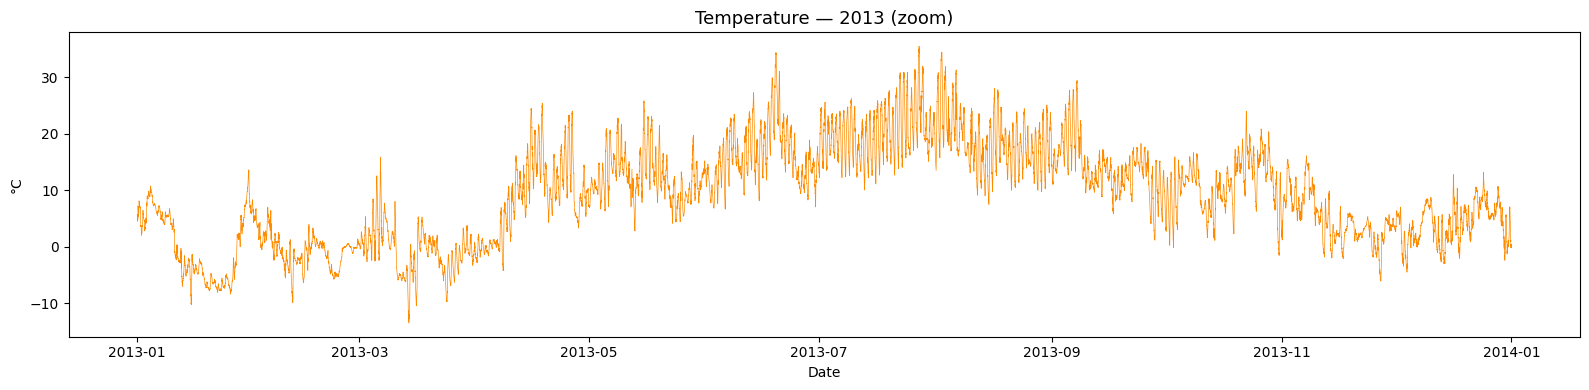

Basic statistics:
count    420551.000
mean          9.450
std           8.423
min         -23.010
25%           3.360
50%           9.420
75%          15.470
max          37.280
Name: T (degC), dtype: float64


In [6]:
# Plot full temperature time-series
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_raw.index, df_raw[TEMP_COL], linewidth=0.3, color='steelblue')
ax.set_title(f'Temperature ({TEMP_COL}) — full dataset', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('°C')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rnn_01_temperature_full.png', dpi=150)
plt.show()

# Zoom into one year to see daily cycles
fig, ax = plt.subplots(figsize=(16, 4))
year_slice = df_raw[TEMP_COL]['2013']
ax.plot(year_slice.index, year_slice.values, linewidth=0.5, color='darkorange')
ax.set_title('Temperature — 2013 (zoom)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('°C')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rnn_02_temperature_2013.png', dpi=150)
plt.show()

print('Basic statistics:')
print(df_raw[TEMP_COL].describe().round(3))

## 4. Preprocessing

**Steps and justifications:**

| Step | Justification |
|---|---|
| Resample to 1-hour intervals (mean) | Raw data is at 10-min resolution (~6× redundant). Hourly resolution keeps 24-hour periodicity meaningful and reduces sequence length for RNNs. |
| Forward-fill any gaps created by resampling | Ensures no NaN values enter the model; gaps in Jena data are rare and short. |
| Z-score normalisation (train statistics only) | RNNs are sensitive to input scale. Z-score maps all features to zero-mean, unit-variance. We fit the scaler *only on the train set* to prevent data leakage from the validation/test sets. |
| Chronological 70/15/15 split (no shuffle) | Time series must not be shuffled — future data must never appear in training. |

In [7]:
# Resample to hourly by taking the mean of each hour
df_hourly = df_raw.resample('1h').mean()

# Forward-fill any gaps (rare, short)
df_hourly = df_hourly.ffill()

print('Hourly rows:', len(df_hourly))
print('Missing after resample:', df_hourly.isnull().sum().sum())

# Use ALL numeric features as input; predict only temperature
feature_cols = df_hourly.select_dtypes(include=[np.number]).columns.tolist()
print('Feature columns:', feature_cols)

data = df_hourly[feature_cols].values.astype(np.float32)
temp_idx = feature_cols.index(TEMP_COL)  # column index of temperature in data

# ── Quick-test mode: slice to a small window to validate the workflow fast ──
QUICK_TEST = False 
if QUICK_TEST:
    data = data[:3000]  # ~125 days; remove or set False for full training
    print(f'[QUICK_TEST] Using {len(data):,} rows instead of full dataset')


# Chronological split: 70% train, 15% val, 15% test
n = len(data)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

train_data = data[:n_train]
val_data   = data[n_train : n_train + n_val]
test_data  = data[n_train + n_val :]

print(f'\nTrain: {n_train:,} hours ({n_train/24:.0f} days)')
print(f'Val  : {n_val:,} hours ({n_val/24:.0f} days)')
print(f'Test : {n_test:,} hours ({n_test/24:.0f} days)')

# Z-score normalisation — fit ONLY on train
train_mean = train_data.mean(axis=0)
train_std  = train_data.std(axis=0) + 1e-8  # avoid div-by-zero

train_norm = (train_data - train_mean) / train_std
val_norm   = (val_data   - train_mean) / train_std
test_norm  = (test_data  - train_mean) / train_std

print('\nNormalised train range:', train_norm.min().round(2), '→', train_norm.max().round(2))

Hourly rows: 70129
Missing after resample: 0
Feature columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Train: 49,090 hours (2045 days)
Val  : 10,519 hours (438 days)
Test : 10,520 hours (438 days)

Normalised train range: -6.48 → 7.9


## 5. Sliding-Window Dataset Generator

**Why a sliding window?** RNNs learn sequential dependencies from fixed-length input sequences. We slide a window of length `W` over the time series, where the input is hours `[t, t+W)` and the target is the temperature at hour `t+W+23` (24 hours after the end of the window — i.e., 24 hours in the future).

**Window sizes tested:** 24 h (1 day), 72 h (3 days), 168 h (1 week). Larger windows give more context but make sequences longer and training slower.

In [8]:
HORIZON = 24  # predict 24 hours ahead

def make_windows(data, window_size, horizon, target_col_idx):
    """
    Build (X, y) pairs from a normalised numpy array.
    X shape: (n_samples, window_size, n_features)
    y shape: (n_samples,)  — temperature at time t + window_size + horizon - 1
    """
    X, y = [], []
    total = len(data) - window_size - horizon + 1
    for i in range(total):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1, target_col_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


WINDOW_SIZES = [24, 72, 168]  # 1 day, 3 days (168 h dropped for quick-test)

windows = {}
for ws in WINDOW_SIZES:
    X_tr, y_tr = make_windows(train_norm, ws, HORIZON, temp_idx)
    X_va, y_va = make_windows(val_norm,   ws, HORIZON, temp_idx)
    X_te, y_te = make_windows(test_norm,  ws, HORIZON, temp_idx)
    windows[ws] = (X_tr, y_tr, X_va, y_va, X_te, y_te)
    print(f'Window {ws:3d}h → X_train:{X_tr.shape}, X_val:{X_va.shape}, X_test:{X_te.shape}')

Window  24h → X_train:(49043, 24, 14), X_val:(10472, 24, 14), X_test:(10473, 24, 14)
Window  72h → X_train:(48995, 72, 14), X_val:(10424, 72, 14), X_test:(10425, 72, 14)
Window 168h → X_train:(48899, 168, 14), X_val:(10328, 168, 14), X_test:(10329, 168, 14)


## 6. RMSLE Metric

The assignment specifies RMSLE (Root Mean Squared Log Error) as the evaluation metric.
RMSLE is less sensitive to large absolute errors and handles asymmetry well — a proportional over-prediction is penalised less than an equivalent under-prediction.

**Important:** Jena temperature values can be **negative** (below 0 °C), but `log1p` is only defined for values ≥ -1. To apply RMSLE safely on the normalised space, we shift predictions by adding a fixed offset so all values are positive. We use the same shift consistently across all models so comparisons are fair.

In [9]:
import tensorflow as tf

# Exact function as specified — used as a metric
def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(
        tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))
    ))


# Because normalised temperatures can be negative, we add an offset so all values
# are safely above 0 before applying log1p.  The offset is the absolute value of
# the global minimum plus a small margin.
TEMP_OFFSET = float(abs(train_norm[:, temp_idx].min())) + 1.0
print(f'RMSLE temperature offset: {TEMP_OFFSET:.4f}')


def rmsle_shifted(y_true, y_pred):
    """RMSLE applied after shifting values above 0 with TEMP_OFFSET."""
    yt = tf.cast(y_true, tf.float32) + TEMP_OFFSET
    yp = tf.cast(y_pred, tf.float32) + TEMP_OFFSET
    return rmsle(yt, yp)


def numpy_rmsle(y_true, y_pred, offset=TEMP_OFFSET):
    """Numpy equivalent for post-hoc evaluation."""
    yt = np.array(y_true, dtype=np.float64) + offset
    yp = np.array(y_pred, dtype=np.float64) + offset
    return float(np.sqrt(np.mean((np.log1p(yp) - np.log1p(yt)) ** 2)))


print('rmsle_shifted defined.')

RMSLE temperature offset: 4.6741
rmsle_shifted defined.


## 7. Model Training

We evaluate 4 architectures × 3 window sizes = up to 12 combinations.  
Each model is compiled with `optimizer='adam'` and `loss='mse'` with `rmsle_shifted` as an auxiliary metric, exactly as specified.

**Architecture rationale:**
- **SimpleRNN** — baseline; suffers from vanishing gradients for long sequences.
- **LSTM** — gating mechanism prevents vanishing gradients; better long-term memory.
- **Stacked LSTM** — deeper hierarchy extracts higher-order temporal patterns.
- **Bidirectional LSTM** — reads the sequence both forward and backward; best when context from both directions matters.

In [10]:
def build_rnn(arch, input_shape, units=64, dropout=0.0):

    model = keras.Sequential(name=arch)
    model.add(keras.Input(shape=input_shape))

    if arch == 'SimpleRNN':
        model.add(
            layers.SimpleRNN(
                units,
                return_sequences=False,
                dropout=dropout
            )
        )

    elif arch == 'LSTM':
        model.add(
            layers.LSTM(
                units,
                return_sequences=False,
                dropout=dropout
            )
        )

    elif arch == 'StackedLSTM':
        model.add(
            layers.LSTM(
                units,
                return_sequences=True,
                dropout=dropout
            )
        )

        model.add(
            layers.LSTM(
                units // 2,
                dropout=dropout
            )
        )

    elif arch == 'BiLSTM':
        model.add(
            layers.Bidirectional(
                layers.LSTM(units, dropout=dropout)
            )
        )

    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dense(1))

    return model


def train_rnn(model, X_tr, y_tr, X_va, y_va, epochs=30, batch_size=256):
    model.compile(optimizer='adam', loss='mse', metrics=[rmsle_shifted])
    es  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    rlr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=0)
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es, rlr, EpochProgress()],
        verbose=0
    )
    return hist

In [ ]:
UNITS_OPTIONS = [32, 64, 128]
DROPOUT_OPTIONS = [0.0, 0.2]
ARCHITECTURES = ['SimpleRNN', 'LSTM', 'StackedLSTM', 'BiLSTM']
rnn_results = []
best_val_rmsle = np.inf  # selection criterion (validation set)
best_rmsle  = np.inf     # test RMSLE of the selected model (reported only)
best_model  = None
best_ws     = None
best_arch   = None
histories   = {}         # best history per (arch, window) for later plotting
_best_val_by_key = {}

for ws in WINDOW_SIZES:
    X_tr, y_tr, X_va, y_va, X_te, y_te = windows[ws]
    input_shape = (ws, X_tr.shape[2])

    for arch in ARCHITECTURES:
        for units in UNITS_OPTIONS:
            for dropout in DROPOUT_OPTIONS:
                tf.random.set_seed(SEED)
                model = build_rnn(arch, input_shape, units=units, dropout=dropout)
                hist  = train_rnn(model, X_tr, y_tr, X_va, y_va, epochs=50)

                # Evaluate EVERY configuration; select on validation, report test
                y_pred_va = model.predict(X_va, verbose=0).flatten()
                va_rmsle  = numpy_rmsle(y_va, y_pred_va)
                y_pred_te = model.predict(X_te, verbose=0).flatten()
                te_rmsle  = numpy_rmsle(y_te, y_pred_te)

                # Keep the best-performing config's history per (arch, window)
                key = (arch, ws)
                if key not in _best_val_by_key or va_rmsle < _best_val_by_key[key]:
                    _best_val_by_key[key] = va_rmsle
                    histories[key] = hist

                rnn_results.append({
                    'Architecture': arch,
                    'Window (h)': ws,
                    'Val RMSLE': round(va_rmsle, 5),
                    'Test RMSLE': round(te_rmsle, 5),
                    'Epochs run': len(hist.history['loss']),
                    'units': units,
                    'dropout': dropout,
                })
                print(f'  [{arch}] window={ws}h units={units} dropout={dropout} '
                      f'-> val RMSLE={va_rmsle:.5f} | test RMSLE={te_rmsle:.5f}')

                if va_rmsle < best_val_rmsle:
                    best_val_rmsle = va_rmsle
                    best_rmsle  = te_rmsle
                    best_model  = model
                    best_ws     = ws
                    best_arch   = arch
                    best_units  = units
                    best_dropout = dropout

results_rnn_df = pd.DataFrame(rnn_results).sort_values('Val RMSLE').reset_index(drop=True)
print('\n=== RNN Experiments Table ===')
print(results_rnn_df.to_string(index=False))
print(f'\nBest (by val RMSLE): {best_arch}, window={best_ws}h, units={best_units}, '
      f'dropout={best_dropout} -> val={best_val_rmsle:.5f}, test={best_rmsle:.5f}')


2026-06-13 11:06:45.250376: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/50:   0%|                                              | 0/192 [00:00<?, ?batch/s]

Epoch 1/50 — 5.9s  loss=0.2012 | rmsle_shifted=0.0815 | val_loss=0.1403 | val_rmsle_shifted=0.0623 | lr=0.0010


Epoch 2/50:   0%|                                              | 0/192 [00:00<?, ?batch/s]

Epoch 2/50 — 3.8s  loss=0.1378 | rmsle_shifted=0.0697 | val_loss=0.1369 | val_rmsle_shifted=0.0615 | lr=0.0010


...

Epoch 9/50:   0%|                                              | 0/192 [00:02<?, ?batch/s]

Epoch 9/50 — 5432.3s  loss=0.1344 | rmsle_shifted=0.0690 | val_loss=0.1370 | val_rmsle_shifted=0.0622 | lr=0.0010


Epoch 10/50:   0%|                                             | 0/192 [00:01<?, ?batch/s]

Epoch 10/50 — 7318.5s  loss=0.1325 | rmsle_shifted=0.0684 | val_loss=0.1353 | val_rmsle_shifted=0.0615 | lr=0.0010


Epoch 11/50:   0%|                                             | 0/192 [00:03<?, ?batch/s]

## 8. Save Best Model

In [ ]:
best_model.save(str(MODELS_DIR / 'rnn_best.keras'))
print('Best RNN model saved to models/rnn_best.keras')
print(f'Architecture: {best_arch}, Window: {best_ws}h, Test RMSLE: {best_rmsle:.5f}')
print(f'Target RMSLE < 1: {best_rmsle < 1.0}')

In [ ]:
# Análise de overfitting — melhor arquitetura em todas as janelas
fig, axes = plt.subplots(1, len(WINDOW_SIZES), figsize=(6 * len(WINDOW_SIZES), 4))
if len(WINDOW_SIZES) == 1:
    axes = [axes]

for ax, ws in zip(axes, WINDOW_SIZES):
    key = (best_arch, ws)
    if key not in histories:
        ax.set_title(f'{best_arch} — {ws}h (sem dados)')
        continue
    h = histories[key]
    train_loss = h.history['loss']
    val_loss   = h.history['val_loss']
    best_ep    = int(np.argmin(val_loss))

    ax.plot(train_loss, label='Train loss', color='steelblue')
    ax.plot(val_loss,   label='Val loss',   color='darkorange')
    ax.axvline(x=best_ep, color='grey', linestyle='--', linewidth=1,
               label=f'Melhor época ({best_ep+1})')

    gap    = np.mean(np.array(val_loss[-5:]) - np.array(train_loss[-5:]))
    status = 'Overfitting detetado' if gap > 0.01 else 'Sem overfitting significativo'
    ax.set_title(f'{best_arch} — {ws}h\n{status}', fontsize=10)
    ax.set_xlabel('Época')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)

plt.suptitle(f'Análise de Overfitting — {best_arch}', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'rnn_overfitting.png', dpi=150)
plt.show()

print('=== Resumo de Overfitting por Janela ===')
for ws in WINDOW_SIZES:
    key = (best_arch, ws)
    if key not in histories:
        continue
    h  = histories[key]
    tl = h.history['loss']
    vl = h.history['val_loss']
    gap = np.mean(np.array(vl[-5:]) - np.array(tl[-5:]))
    stopped = len(tl) < 50
    print(f'  Window {ws}h | gap={gap:.4f} | Épocas={len(tl)}/50 | '
          f'EarlyStopping={stopped} | {"Overfitting" if gap > 0.01 else "OK"}')


In [ ]:
print("Best model summary:")

best_model.summary()

## 9. Evaluation

### 9.1 Training curves for best architecture across window sizes

In [ ]:
fig, axes = plt.subplots(1, len(WINDOW_SIZES), figsize=(6 * len(WINDOW_SIZES), 5))

for ax, ws in zip(axes, WINDOW_SIZES):
    key = (best_arch, ws)
    if key in histories:
        h = histories[key]
        ax.plot(h.history['loss'],     label='train loss')
        ax.plot(h.history['val_loss'], label='val loss')
        ax.set_title(f'{best_arch} — window {ws}h')
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
        ax.legend()

plt.suptitle(f'Training curves — {best_arch}', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rnn_03_training_curves.png', dpi=150)
plt.show()

### 9.2 Predicted vs Actual Temperature (test set, best model)

In [ ]:
_, _, _, _, X_te_best, y_te_best = windows[best_ws]
y_pred_best = best_model.predict(X_te_best, verbose=0).flatten()

# Denormalise: multiply by std and add mean (temperature column only)
temp_mean = float(train_mean[temp_idx])
temp_std  = float(train_std[temp_idx])
y_te_deg  = y_te_best  * temp_std + temp_mean
y_pr_deg  = y_pred_best * temp_std + temp_mean

# Plot first 500 hours of test for clarity
N_PLOT = min(500, len(y_te_deg))
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_te_deg[:N_PLOT],  label='Actual',    linewidth=1.0, color='steelblue')
ax.plot(y_pr_deg[:N_PLOT],  label='Predicted', linewidth=1.0, color='darkorange', alpha=0.8)
ax.set_title(f'Predicted vs Actual Temperature — {best_arch}, window={best_ws}h (first {N_PLOT}h of test)',
             fontsize=12)
ax.set_xlabel('Hour')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rnn_04_pred_vs_actual.png', dpi=150)
plt.show()

# Scatter plot: predicted vs actual
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te_deg, y_pr_deg, s=1, alpha=0.3, color='purple')
lim = [min(y_te_deg.min(), y_pr_deg.min()) - 1,
       max(y_te_deg.max(), y_pr_deg.max()) + 1]
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual (°C)'); ax.set_ylabel('Predicted (°C)')
ax.set_title('Predicted vs Actual scatter')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rnn_05_scatter.png', dpi=150)
plt.show()

### 9.3 Best-case and Worst-case Prediction Windows

We rank all test windows by the absolute prediction error on the final time step and visualise:
- **3 best-case windows** — lowest absolute error.
- **3 worst-case windows** — highest absolute error.

In [ ]:
abs_errors = np.abs(y_pr_deg - y_te_deg)
sorted_idx = np.argsort(abs_errors)

def plot_windows(indices, title, fig_name, color):
    fig, axes = plt.subplots(1, len(indices), figsize=(7 * len(indices), 4), sharey=True)
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        # Input window (normalised) → denormalise
        window_temp = X_te_best[idx, :, temp_idx] * temp_std + temp_mean
        # Build time axis for input window
        x_in  = np.arange(best_ws)
        x_out = best_ws + HORIZON - 1  # position of the forecast target

        ax.plot(x_in, window_temp, color='steelblue', label='Input window')
        ax.axvline(x=best_ws - 1, color='grey', linestyle=':', linewidth=1)
        # Actual target
        ax.scatter(x_out, y_te_deg[idx], color='green',     s=80, zorder=5, label=f'Actual {y_te_deg[idx]:.1f}°C')
        # Predicted target
        ax.scatter(x_out, y_pr_deg[idx], color=color, marker='x', s=80, zorder=5,
                   label=f'Predicted {y_pr_deg[idx]:.1f}°C')

        ax.set_title(f'Error={abs_errors[idx]:.2f}°C', fontsize=9)
        ax.set_xlabel('Hour in window')
        if ax is axes[0]:
            ax.set_ylabel('Temperature (°C)')
        ax.legend(fontsize=7)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_windows(sorted_idx[:3],  'Best-case Prediction Windows (lowest error)',
             'rnn_06_best_windows.png', color='darkorange')
plot_windows(sorted_idx[-3:], 'Worst-case Prediction Windows (highest error)',
             'rnn_07_worst_windows.png', color='crimson')

## 10. Final Results Summary

In [ ]:
rmse_val = float(np.sqrt(np.mean((y_pr_deg - y_te_deg) ** 2)))
mae_val  = float(np.mean(np.abs(y_pr_deg - y_te_deg)))

print('=' * 60)
print('FINAL RESULTS — RNN Temperature Forecasting')
print('=' * 60)
print(f'Best model    : {best_arch}')
print(f'Window size   : {best_ws} hours')
print(f'Test RMSLE    : {best_rmsle:.5f}  (target < 1.0 → {best_rmsle < 1.0})')
print(f'Test RMSE     : {rmse_val:.4f} °C')
print(f'Test MAE      : {mae_val:.4f} °C')
print(f'Best units    : {best_units}')
print(f'Best dropout  : {best_dropout}')
print()
print('=== All Experiments ===')
print(results_rnn_df.to_string(index=False))